# Data Mining

## Preamble

### Modules

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import plotly.express as px
import plotly.io as pio
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from itertools import combinations
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

from utils.utils import load_and_drop_na_data

### Loading Data

In [3]:
df = load_and_drop_na_data('../data/transformed/transformed.csv')

Raw data: 406585 rows
Removed 5223 duplicates
Clean data: 401362 rows


In [4]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

### Configuration

In [20]:
pio.renderers.default = 'notebook_connected'

## Market Basket Analysis

### Preamble

The algorithm that will be used is the Apriori algorithm.

The following terms will be used:

- _itemset_: This represents a collection of one or more items.
- _transaction_: This represents an itemset purchased by a single user with an attached InvoiceNo.

### Objective

The aim of this analysis is to evaluate over multiple transactions the precursor itemset $X$ and successor itemset $Y$ and their correlation. That is, if an itemset $X$ is bought how does it affect the purchase of an itemset. The correlation can be:

- **Positive:** When $X$ is bought then $Y$ is likely to be bought in a certain percentage of transactions. That is, purchasing $X$ encourages customers to purchase $Y$. 
- **Negative:** When $X$ is bought then $Y$ is unlikely to be bought in a certian percentage of transactions. That is, purchasing $Y$ discourages customers from purchasing $Y$.
- **Neutral:** When $X$ is bought there is no influence on the purchase of $Y$.

This correlation is mapped out by three variables:

- Support
- Confidence
- Lift

Lift is used to handle the possibility of a spurious correlation between $X$ and $Y$.

### Key Metrics

#### Support

This is the fraction of transactions containing $X$:

$$\mathrm{supp}(X) = \frac{\lvert \{\,t \mid X \subseteq t\} \rvert}{\lvert \text{Transactions} \rvert}$$

For a rule $X \Rightarrow Y$:

$$\mathrm{supp}(X \cup Y)$$

#### Confidence

This is the probability that Y will occur given X:

$$\mathrm{conf}(X \Rightarrow Y) = P(Y \mid X) = \frac{\mathrm{supp}(X \cap Y)}{\mathrm{supp}(X)}$$

It focuses on reflecting how reliable the implication is.

#### Lift

It measures how much more often $X$ and $Y$ occur together than if independent.

This handles the scenario where both $X$ and $Y$ are popular. The support and confidence can make it seem that $X$ has a positive effect on $Y$ when in reality $Y$ is actually really popular and its sales are from its own popularity.

$$\mathrm{lift}(X \Rightarrow Y) = \frac{\mathrm{supp}(X \cap Y)}{\mathrm{supp}(X)\cdot \mathrm{supp}(Y)}
= \frac{\mathrm{conf}(X \Rightarrow Y)}{\mathrm{supp}(Y)}$$

- Lift > 1 -> Positive association
- Lift = 1 -> Independence
- Lift < 1 -> Negative association

Independence in this case means that $X$ has no impact on $Y$ and that they are both popular or unpopular on their own.

### Visual Illustrations

#### Support

<img src="https://miro.medium.com/max/403/0*pyOADkeaWyrVP2ft.png" />

#### Simulated Transactions

<img src='https://annalyzin.files.wordpress.com/2016/04/association-rule-support-table.png?w=503&h=447' />

#### Confidence

<img src='https://miro.medium.com/max/576/1*50GI4dR58MnhwBP9dw6nFQ.png' />

<img src='https://annalyzin.files.wordpress.com/2016/03/association-rule-confidence-eqn.png?w=527&h=77' />

#### Lift

<img src='https://annalyzin.files.wordpress.com/2016/03/association-rule-lift-eqn.png?w=566&h=80' />

### Apriori Algorithm

In [6]:
apriori_df = df.dropna(subset=["InvoiceNo", "Description"])

apriori_df["Description"] = apriori_df["Description"].str.strip().str.lower()

transactions = apriori_df.groupby("InvoiceNo")["Description"].apply(list).tolist()

In [7]:
transactions[:2]

[['white hanging heart t-light holder',
  'white metal lantern',
  'cream cupid hearts coat hanger',
  'knitted union flag hot water bottle',
  'red woolly hottie white heart.',
  'set 7 babushka nesting boxes',
  'glass star frosted t-light holder'],
 ['hand warmer union jack', 'hand warmer red polka dot']]

In [8]:
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
apriori_df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

In [9]:
apriori_df_encoded.head()

,10 colour spaceboy pen,12 coloured party balloons,12 daisy pegs in wood box,12 egg house painted wood,12 hanging eggs hand painted,12 ivory rose peg place settings,12 message cards with envelopes,12 pencil small tube woodland,12 pencils small tube red retrospot,12 pencils small tube skull,...,zinc star t-light holder,zinc sweetheart soap dish,zinc sweetheart wire letter rack,zinc t-light holder star large,zinc t-light holder stars large,zinc t-light holder stars small,zinc top 2 door wooden shelf,zinc willie winkie candle stick,zinc wire kitchen organiser,zinc wire sweetheart letter tray
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


The minimum support is set at **0.01%**. This means that any itemset appearing in **4,000** or more transactions is considered frequent. This is a safe balanced choice.

In [10]:
frequent_itemsets = apriori(apriori_df_encoded, min_support=0.01, use_colnames=True).sort_values(by="support", ascending=False).reset_index(drop=True)

In [11]:
len(frequent_itemsets)

740

In [12]:
frequent_itemsets[:5]

,support,itemsets
0,0.090749,(white hanging heart t-light holder)
1,0.084844,(regency cakestand 3 tier)
2,0.074069,(jumbo bag red retrospot)
3,0.063069,(party bunting)
4,0.062303,(assorted colour bird ornament)


In [13]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1).sort_values(by="lift", ascending=False).reset_index(drop=True)

In [14]:
rules.head(5)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(set/6 red spotty paper cups),(set/6 red spotty paper plates),0.012848,0.014652,0.010639,0.828070,56.517700,1.0,0.010451,5.731109,0.995092,0.631016,0.825514,0.777112
1,(set/6 red spotty paper plates),(set/6 red spotty paper cups),0.014652,0.012848,0.010639,0.726154,56.517700,1.0,0.010451,3.604768,0.996913,0.631016,0.722590,0.777112
2,(regency tea plate roses),(regency tea plate green),0.015328,0.012397,0.010459,0.682353,55.039829,1.0,0.010269,3.109119,0.997115,0.605744,0.678365,0.762995
3,(regency tea plate green),(regency tea plate roses),0.012397,0.015328,0.010459,0.843636,55.039829,1.0,0.010269,6.297323,0.994156,0.605744,0.841202,0.762995
4,(poppy's playhouse kitchen),(poppy's playhouse bedroom),0.015733,0.014381,0.011496,0.730659,50.807143,1.0,0.011270,3.659373,0.995988,0.617433,0.726729,0.765016


In [15]:
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

In [24]:
fig = px.scatter(
    rules,
    x="support",
    y="confidence",
    size="lift",
    color="lift",
    hover_data=["antecedents_str", "consequents_str"],
    title="Association Rules: Support vs Confidence (size = lift)"
)

In [25]:
fig.show()

## Clustering

### Preamble

The clustering approach will be customer segmentation, grouping customers based on aggregated transactional behaviour like:

- Purchase Frequency
- Recency
- Monetary Value

The K-Means Clustering algorithm will be employed due to:

- The size of the dataset
- The aim of finding homogenous clusters of customer behaviour

It should be noted that $K$ represents some number of clusters uncovered by the clustering model.

### Understanding the Algorithm

K-Means is an **unsupervised centroid-based** clustering that partitions the customers into K clusters where each point belongs to the cluster with the **nearest mean**.

The algorithm seeks to minimize the **within-cluster sum of squares (WCSS)**. That is the sum of squared distances between each point and its cluster centroid.

Mathematically, this is expressed as follows:

$$\min_{\{S_i\}_{i=1}^K} \sum_{i=1}^{K} \sum_{\mathbf{x} \in S_i} \lVert \mathbf{x} - \boldsymbol{\mu}_i \rVert^2$$

Where:

$$\boldsymbol{\mu}_i = \frac{1}{\lvert S_i \rvert} \sum_{\mathbf{x} \in S_i} \mathbf{x}$$

With $S_1$ being the set of points in cluster $i$ and $\mu_{i}$ its centroid.

### Suitability

K-Means is suitable since:

- It considers the numerical features derived
- It produces exclusive clusters with each customer belonging to only one segment
- The results are directly actionable since clusters can be labelled as "high spenders", "frequent buyers" or "low frequency visitors" enabling strategies to be tailored accordingly.

### K-Means Clustering Algorithm

In [28]:
kmeans_df = df.copy()
kmeans_df['TotalPrice'] = kmeans_df['Quantity'] * kmeans_df['UnitPrice']

In [29]:
kmeans_df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [36]:
customer_kmeans_df = kmeans_df.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',                  # Number of transactions
    'Quantity': 'sum',                       # Total items bought
    'TotalPrice': 'sum',                     # Total amount spent
    'UnitPrice': 'mean',                     # Average unit price
}).rename(columns={
    'InvoiceNo': 'NumTransactions',
    'Quantity': 'TotalItems',
    'TotalPrice': 'TotalSpent',
    'UnitPrice': 'AvgUnitPrice'
}).sort_values(by="NumTransactions", ascending=False).reset_index()


In [37]:
customer_kmeans_df.head(5)

,CustomerID,NumTransactions,TotalItems,TotalSpent,AvgUnitPrice
0,14911.0,248,83825,155590.31,5.262821
1,12748.0,224,26826,37702.07,3.296605
2,17841.0,169,23040,41170.63,2.554579
3,14606.0,128,6433,12518.95,2.819304
4,15311.0,118,38621,61981.31,2.520218


In [39]:
features = ['NumTransactions', 'TotalItems', 'TotalSpent', 'AvgUnitPrice']
X = customer_kmeans_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [41]:
kmeans = KMeans(n_clusters=4, random_state=42)
customer_kmeans_df['Cluster'] = kmeans.fit_predict(X_scaled)

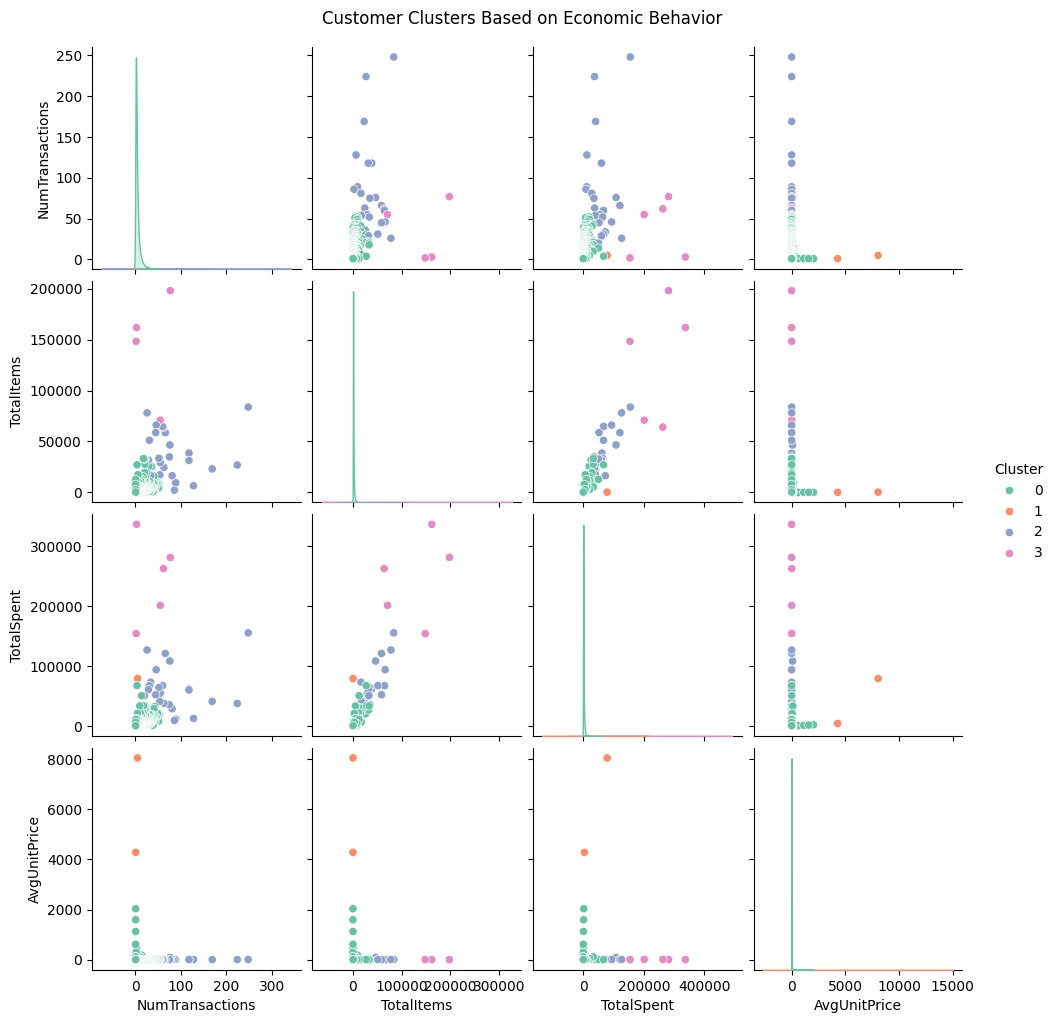

In [44]:
sns.pairplot(customer_kmeans_df, vars=features, hue='Cluster', palette='Set2')
plt.suptitle("Customer Clusters Based on Economic Behavior", y=1.02)
plt.show()

In [46]:
cluster_summary = customer_kmeans_df.groupby('Cluster')[features].mean()
print(cluster_summary)

         NumTransactions     TotalItems     TotalSpent  AvgUnitPrice
Cluster                                                             
0               4.607793     901.894628    1548.436605      5.161208
1               3.000000      91.500000   41735.565000   6171.705000
2              83.041667   36736.916667   61432.276667      6.999542
3              39.800000  128749.600000  247450.944000      5.355333


- Cluster `0`: **Low-Value Occasional Buyers**
- Cluster `1`: **High-End Luxury Shoopers**
- Cluster `2`: **Frequent High-Volume Buyers**
- Cluster `3`: **Elite Bulk Buyers**

## High Utility Itemset Mining

### Preamble

High Utility Itemset Mining **(HUIM)** identifies the most valuable combination of products in the data considering both the quantity and price. The focus in this particular algorithm is locating the most econmomically viable itemsets.

### Objective

This algorithm handles the blind spot of frequent itemset identification. That is, a frequent itemset can be of little economic value. Or an infrequent itemset can be of great economic value.

Utilising only the frequent itemset algorithm may have a business stocking up on items that although bought often do not translate into tangible economic benefits.

However, incorporating both algorithms uncovers the following groups:

- Frequent High Value Itemsets
- Frequent Low Value Itemsets
- Infrequent High Value Itemsets
- Infrequent Low Value Itemsets

This discovery allows a business to focus more on their frequent high value itemsets enabling them to greatly increase their profit margins.

### BTS of the Algorithm

The utility of an item $i$ in a transaction is:

$$utility(i, t) = quantity_{i,t} \times unit\_price_{i, t}$$

The utility itemset $X$ in transaction $t$ is:

$$u(X, t) = \sum_{i \in X} u(i, t)$$

The total utility of $X$ across the dataset is:

$$U(X) = \sum_{t \in D\;:\;X \subseteq t} u(X, t)$$

### HUIM Algorithm

In [47]:
huim_df = df.copy()
huim_df['Utility'] = huim_df['Quantity'] * huim_df['UnitPrice']

In [48]:
huim_df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Utility
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34,20.34


In [50]:
utility_matrix = huim_df.pivot_table(
    index='InvoiceNo',
    columns='Description',
    values='Utility',
    aggfunc='sum',
    fill_value=0
)

In [51]:
utility_matrix.head(5)

Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536366,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536367,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536368,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [52]:
item_utilities = utility_matrix.sum().sort_values(ascending=False)

utility_threshold = 10000  # Set based on your dataset
high_utility_items = item_utilities[item_utilities > utility_threshold]
print(high_utility_items)

Description
PAPER CRAFT , LITTLE BIRDIE           336939.20
Manual                                169791.84
MEDIUM CERAMIC TOP STORAGE JAR        158896.37
REGENCY CAKESTAND 3 TIER              152063.80
WHITE HANGING HEART T-LIGHT HOLDER    107016.40
                                        ...    
SOLDIERS EGG CUP                       10203.00
GARDENERS KNEELING PAD CUP OF TEA      10165.29
REVOLVER WOODEN RULER                  10126.14
LUNCH BAG VINTAGE LEAF DESIGN          10058.55
TRADITIONAL WOODEN SKIPPING ROPE       10036.49
Length: 195, dtype: float64


In [55]:
# Keep only high utility columns
filtered_huim_matrix = utility_matrix[high_utility_items.index]

# Generate 2-item combinations
itemsets = list(combinations(filtered_huim_matrix.columns, 2))

# Compute utility of each itemset
high_utility_itemsets = {}

for item1, item2 in itemsets:
    total_utility = (filtered_huim_matrix[item1] + filtered_huim_matrix[item2]).sum()
    if total_utility > utility_threshold:
        high_utility_itemsets[(item1, item2)] = total_utility

# View top itemsets
high_utility_itemsets = dict(sorted(high_utility_itemsets.items(), key=lambda x: x[1], reverse=True))
df_huim_utility = pd.DataFrame(
    [(items, utility) for items, utility in high_utility_itemsets.items()],
    columns=["Itemset", "Utility"]
)

In [56]:
df_huim_utility.head(5)

,Itemset,Utility
0,"(PAPER CRAFT , LITTLE BIRDIE, Manual)",506731.04
1,"(PAPER CRAFT , LITTLE BIRDIE, MEDIUM CERAMIC T...",495835.57
2,"(PAPER CRAFT , LITTLE BIRDIE, REGENCY CAKESTAN...",489003.00
3,"(PAPER CRAFT , LITTLE BIRDIE, WHITE HANGING HE...",443955.60
4,"(PAPER CRAFT , LITTLE BIRDIE, POSTAGE)",425836.88


## Time Series

### Preamble

The **Auto-Regressive Integrated Moving Average (ARIMA)** algorithm will be employed.

The model works based on three combined components:

- **AR** models the series using its own past values
- **I** uses differencing to make a non-stationary series stationary
- **MA** models the current value of the series as a function of past forecast errors

### Objective

This enables:

- Revealing trends, seasonality and irregular patterns
- Forecasting future demand to optimize inventory and marketing
- Detecting seasonal cycles like weekly or holiday spikes
- Identifying anomalies which could indicate fraud, data issues or promotional impacts

### Deconstructing the Algorithm

To make the series stationary- that is, having a constant mean and variance- differencing is applied:

$$y'_t = y_t - y_{t-1}$$

Higher-order differencing may also be applied depending on the complexity of the data. Moreover, seasonal differencing may prove invaluable in when the aim is to group time intervals.

The current vaue is modelled after past values in the Auto-Regressive phase:

$$X_t = \sum_{i=1}^{p} \varphi_i X_{t-i} + \varepsilon_t$$

For the Moving Average the current value is modelled based on past forecast errors:

$$X_t = \varepsilon_t + \sum_{i=1}^{q} \theta_i \varepsilon_{t-i}$$

When all of this is put together the combined **ARIMA(p, d, q)** model using the lag operator $L$ with an optional constant term representing drift has the general form:

$$\left(1 - \sum_{i=1}^p \varphi_i L^i\right) (1 - L)^d X_t = \delta + \left( 1 + \sum_{i=1}^{q} \theta_i L^i \right) \varepsilon_t$$

Finally the fitted model is used to project future values and compute forecast intervals, usually:

$$\hat y_{T+h|T} \; \pm \; 1.96 \sqrt{v_{T+h|T}}$$

Where $v_{T+h|T}$ is the forecast variance.

### ARIMA Model

In [69]:
arima_df = df.copy()
arima_df['TotalPrice'] = arima_df['Quantity'] * arima_df['UnitPrice']

In [70]:
arima_df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [71]:
arima_df['InvoiceDate'] = pd.to_datetime(arima_df['InvoiceDate'], errors='coerce')
arima_df = arima_df.dropna(subset=['InvoiceDate'])

In [72]:
arima_df.set_index('InvoiceDate', inplace=True)
print(type(arima_df.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [73]:
ts = arima_df['TotalPrice'].resample('D').sum()
ts = ts.fillna(0)

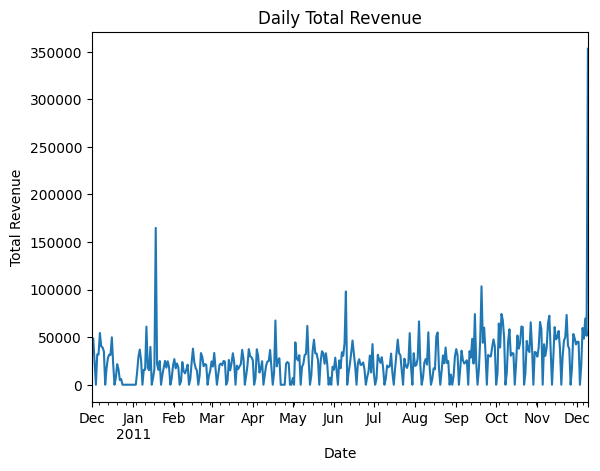

In [74]:
ts.plot(title="Daily Total Revenue")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.show()

In [ ]:
model = auto_arima(ts, seasonal=False, trace=True, suppress_warnings=True)
print(model.summary())

In [ ]:
# Fit ARIMA with the best order found
best_order = model.order  # e.g., (1,1,2)
arima_model = ARIMA(ts, order=best_order)
arima_result = arima_model.fit()

In [ ]:
n_days = 30  # Forecast next 30 days
forecast = arima_result.forecast(steps=n_days)

# Plot historical + forecast
plt.figure(figsize=(10, 5))
plt.plot(ts, label='Historical')
plt.plot(pd.date_range(ts.index[-1], periods=n_days+1, freq='D')[1:], forecast, label='Forecast', color='red')
plt.legend()
plt.title("ARIMA Forecast of Daily Revenue")
plt.show()

In [ ]:
arima_result.plot_diagnostics(figsize=(12, 8))
plt.show()

In [ ]:
ts = ts.astype(float)

# Define train/test split
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

In [ ]:
# Rolling forecast origin
history = list(train)
predictions = []

for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))  # (p,d,q): adjust if needed
    model_fit = model.fit()
    
    # Forecast next step
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    
    # Append true value to history
    history.append(test[t])

In [ ]:
# Evaluation
mse = mean_squared_error(test, predictions)
print(f'Mean Squared Error: {mse:.2f}')

In [ ]:
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Actual': test.values,
    'Predicted': predictions
}, index=test.index)

In [ ]:
# Plotting
plt.figure(figsize=(14, 5))
plt.plot(comparison_df['Actual'], label='Actual', color='blue')
plt.plot(comparison_df['Predicted'], label='Predicted', color='orange')
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(comparison_df.head(10))  # View side-by-side comparison